# Fine-tune NusaBERT-large on NusaX-Senti

Fine-tune NusaBERT-large untuk sentiment classification pada 4 bahasa target:
- Javanese (jav)
- Sundanese (sun)
- Acehnese (ace)
- Banjarese (bjn)

Berdasarkan script dari [LazarusNLP/NusaBERT](https://github.com/LazarusNLP/NusaBERT)

Tujuan: mendapatkan sentiment classifier per bahasa yang akan digunakan sebagai
tool di Sentiment Validator Agent.

In [1]:
# Install dependencies
# !pip install transformers datasets evaluate accelerate scikit-learn

In [4]:
import evaluate
import numpy as np
from datasets import load_dataset, ClassLabel
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
import torch

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

y:\Michh\Python\Projects\MAGenerator\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [5]:
# Clear GPU memory dari run sebelumnya
import torch
import gc

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()
    print(f"VRAM after clear: {torch.cuda.memory_allocated()/1024**2:.0f} MB allocated")
    print(f"VRAM reserved: {torch.cuda.memory_reserved()/1024**2:.0f} MB reserved")
    print(f"GPU: {torch.cuda.get_device_name(0)}")

VRAM after clear: 0 MB allocated
VRAM reserved: 0 MB reserved
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
# Konfigurasi â€” NusaBERT-large hyperparams sesuai paper Table 4 + GitHub run_classification.sh
MODEL_CHECKPOINT = "LazarusNLP/NusaBERT-large"
DATASET_NAME = "indonlp/NusaX-senti"
# TARGET_LANGS = ["jav", "sun", "ace", "bjn"]
TARGET_LANGS = ["ace", "ban", "bbc", "bjn", "bug", "eng", "ind", "jav", "mad", "min", "nij", "sun"]
INPUT_MAX_LENGTH = 128

# Hyperparameters (dari paper + GitHub, NusaBERT-large)
NUM_TRAIN_EPOCHS = 100
LEARNING_RATE = 2e-5        # large = 2e-5 (base = 1e-5)
WEIGHT_DECAY = 0.01
TRAIN_BATCH_SIZE = 16        # paper = 16, -> VRAM 8GB tidak cukup â†’ 4 + grad_accum 4
EVAL_BATCH_SIZE = 64      # paper = 64, turunkan untuk VRAM
# GRADIENT_ACCUMULATION_STEPS = 4  # effective batch = 4 * 4 = 16 (sama dengan paper)
EARLY_STOPPING_PATIENCE = 5

# Random seed untuk reproducibility
SEED = 42

OUTPUT_BASE_DIR = "../outputs/nusabert-sentiment-large-syn"

In [5]:
def finetune_nusabert(lang_code: str):
    """
    Fine-tune NusaBERT pada NusaX-Senti untuk satu bahasa.
    Berdasarkan: https://github.com/LazarusNLP/NusaBERT/blob/main/scripts/run_classification.py
    """
    model_name = MODEL_CHECKPOINT.split("/")[-1].lower()
    print(f"\n{'='*50}")
    print(f"Fine-tuning {model_name} on NusaX-Senti [{lang_code}]")
    print(f"{'='*50}")
    
    from datasets import Dataset, DatasetDict, Features, Value, ClassLabel as CL
    from transformers import AutoConfig, BertForSequenceClassification, BertTokenizerFast
    import pandas as pd
    
    data_dir = f"../data/nusax_senti/{lang_code}"
    train_df = pd.read_csv(f"{data_dir}/train.csv")
    valid_df = pd.read_csv(f"{data_dir}/valid.csv")
    test_df = pd.read_csv(f"{data_dir}/test.csv")
    
    label_list = sorted(train_df["label"].unique().tolist())
    label2id = {v: i for i, v in enumerate(label_list)}
    id2label = {i: v for i, v in enumerate(label_list)}
    num_labels = len(label_list)
    print(f"Labels: {label_list} â†’ {label2id}")
    
    for df in [train_df, valid_df, test_df]:
        df["label"] = df["label"].map(label2id)
    
    features = Features({
        "id": Value("int64"),
        "text": Value("string"),
        "label": CL(names=label_list),
    })
    
    dataset = DatasetDict({
        "train": Dataset.from_pandas(train_df, features=features, preserve_index=False),
        "validation": Dataset.from_pandas(valid_df, features=features, preserve_index=False),
        "test": Dataset.from_pandas(test_df, features=features, preserve_index=False),
    })
    print(f"Train: {len(dataset['train'])}, Valid: {len(dataset['validation'])}, Test: {len(dataset['test'])}")
    
    tokenizer = BertTokenizerFast.from_pretrained(MODEL_CHECKPOINT)
    config = AutoConfig.from_pretrained(MODEL_CHECKPOINT)
    config.num_labels = num_labels
    config.label2id = label2id
    config.id2label = id2label
    
    model = BertForSequenceClassification.from_pretrained(
        MODEL_CHECKPOINT, config=config, ignore_mismatched_sizes=True,
    )
    total_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"Model: {model_name} ({total_params:.0f}M params)")
    
    def preprocess_function(examples):
        return tokenizer(examples["text"], max_length=INPUT_MAX_LENGTH, truncation=True)
    
    tokenized_dataset = dataset.map(preprocess_function, batched=True)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    
    f1_metric = evaluate.load("f1")
    accuracy_metric = evaluate.load("accuracy")
    
    def compute_metrics(eval_pred):
        predictions, labels = eval_pred
        predictions = np.argmax(predictions, axis=1)
        f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")
        acc = accuracy_metric.compute(predictions=predictions, references=labels)
        return {"f1": round(f1["f1"], 4), "accuracy": round(acc["accuracy"], 4)}
    
    output_dir = f"{OUTPUT_BASE_DIR}/{model_name}-{lang_code}"
    
    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        # gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        optim="adamw_torch_fused",
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        num_train_epochs=NUM_TRAIN_EPOCHS,
        save_total_limit=3,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        bf16=torch.cuda.is_available(),
        report_to="none",
        logging_steps=16,
        seed=SEED,
        data_seed=SEED,
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(EARLY_STOPPING_PATIENCE)],
    )
    
    trainer.train()
    
    test_results = trainer.evaluate(tokenized_dataset["test"])
    print(f"\nTest Results [{lang_code}] ({model_name}):")
    print(f"F1 (macro): {test_results['eval_f1']:.4f}")
    print(f"Accuracy:   {test_results['eval_accuracy']:.4f}")
    
    best_model_dir = f"{output_dir}/best"
    trainer.save_model(best_model_dir)
    tokenizer.save_pretrained(best_model_dir)
    print(f"  Saved to: {best_model_dir}")
    
    return test_results

## Fine-tune per Bahasa

Jalankan fine-tuning untuk masing-masing bahasa target.
Setiap bahasa menghasilkan 1 model classifier yang disimpan di `outputs/nusabert-sentiment/`.

Target F1 (dari paper NusaBERT): jav 87.2%, sun 82.7%, ace 81.8%, bjn 86.5%

In [6]:
# Fine-tune Javanese
# results_jav = finetune_nusabert("jav")

In [7]:
# Fine-tune Sundanese
# results_sun = finetune_nusabert("sun")

In [8]:
# Fine-tune Acehnese
# results_ace = finetune_nusabert("ace")

In [9]:
# Fine-tune Banjarese
# results_bjn = finetune_nusabert("bjn")

## Ringkasan Hasil

In [10]:
# # Ringkasan
# import pandas as pd

# all_results = {
#     "jav": results_jav,
#     "sun": results_sun,
#     "ace": results_ace,
#     "bjn": results_bjn,
# }

# # Paper reference scores
# paper_scores = {"jav": 87.2, "sun": 82.7, "ace": 81.8, "bjn": 86.5}

# summary = []
# for lang, res in all_results.items():
#     summary.append({
#         "Language": lang,
#         "Our F1 (%)": round(res["eval_f1"] * 100, 2),
#         "Paper F1 (%)": paper_scores[lang],
#         "Our Accuracy (%)": round(res["eval_accuracy"] * 100, 2),
#     })

# df_summary = pd.DataFrame(summary)
# print("NusaBERT-large Fine-tuning Results on NusaX-Senti (test set)")
# print("=" * 60)
# display(df_summary)
# print("\nPaper scores from: LazarusNLP/NusaBERT (arXiv:2403.01817)")

## Test: Predict Sentiment pada Kalimat Baru

Coba predict pada beberapa kalimat buat lihat output confidence.

In [11]:
from transformers import pipeline

# Load model yang sudah di-fine-tune
lang = "jav"  # ganti sesuai bahasa yang mau ditest
model_path = f"{OUTPUT_BASE_DIR}/nusabert-large-{lang}/best"

classifier = pipeline("sentiment-analysis", model=model_path, tokenizer=model_path)

# Test kalimat
test_sentences = [
    "Panganan e enak tenan, regane mirah",          # positive
    "Pelayanane ala banget, ora profesional",        # negative  
    "Toko iki buka jam 8 esuk sampek jam 10 bengi",  # neutral
]

for sent in test_sentences:
    result = classifier(sent, top_k=3)
    print(f"\nText: {sent}")
    for r in result:
        print(f"  {r['label']}: {r['score']:.4f}")

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 9432.25it/s]



Text: Panganan e enak tenan, regane mirah
  positive: 0.9842
  negative: 0.0096
  neutral: 0.0062

Text: Pelayanane ala banget, ora profesional
  negative: 0.9800
  neutral: 0.0172
  positive: 0.0028

Text: Toko iki buka jam 8 esuk sampek jam 10 bengi
  neutral: 0.9959
  negative: 0.0027
  positive: 0.0014


## Hasil Fine-tuning NusaBERT-large (dari script .py)

Load model yang sudah di-train dari `outputs/nusabert-sentiment/`.
Urutan: Training History â†’ Evaluate Test Set â†’ Test Predict.

In [6]:
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from transformers import pipeline
import evaluate

MODEL_NAME = "nusabert-large"
# ALL_LANGS = ["ace", "ban", "bbc", "bjn", "bug", "eng", "ind", "jav", "mad", "min", "nij", "sun"]
ALL_LANGS = ["jav", "sun", "ace", "bjn", "mad", "min", "ban"]
BASE_DIR = Path("../outputs/nusabert-sentiment-large-syn")
# BASE_DIR = Path("../outputs/nusabert-sentiment")  # IGNORE
DATA_DIR = Path("../data/nusax_senti")

# Paper reference (NusaBERT-large, Table 6)
paper_scores = {
    "ace": 81.8, "ban": 82.8, "bbc": 74.7, "bjn": 86.5, "bug": 73.4,
    "eng": 84.6, "ind": 93.3, "jav": 87.2, "mad": 82.5, "min": 83.5,
    "nij": 77.7, "sun": 82.7,
}

print(f"Model: {MODEL_NAME}")
print(f"Output dir: {BASE_DIR}")
print(f"Available: {[l for l in ALL_LANGS if (BASE_DIR / f'{MODEL_NAME}-{l}' / 'best').exists()]}")

Model: nusabert-large
Output dir: ..\outputs\nusabert-sentiment-large-syn
Available: ['jav', 'sun', 'ace', 'bjn', 'mad', 'min', 'ban']


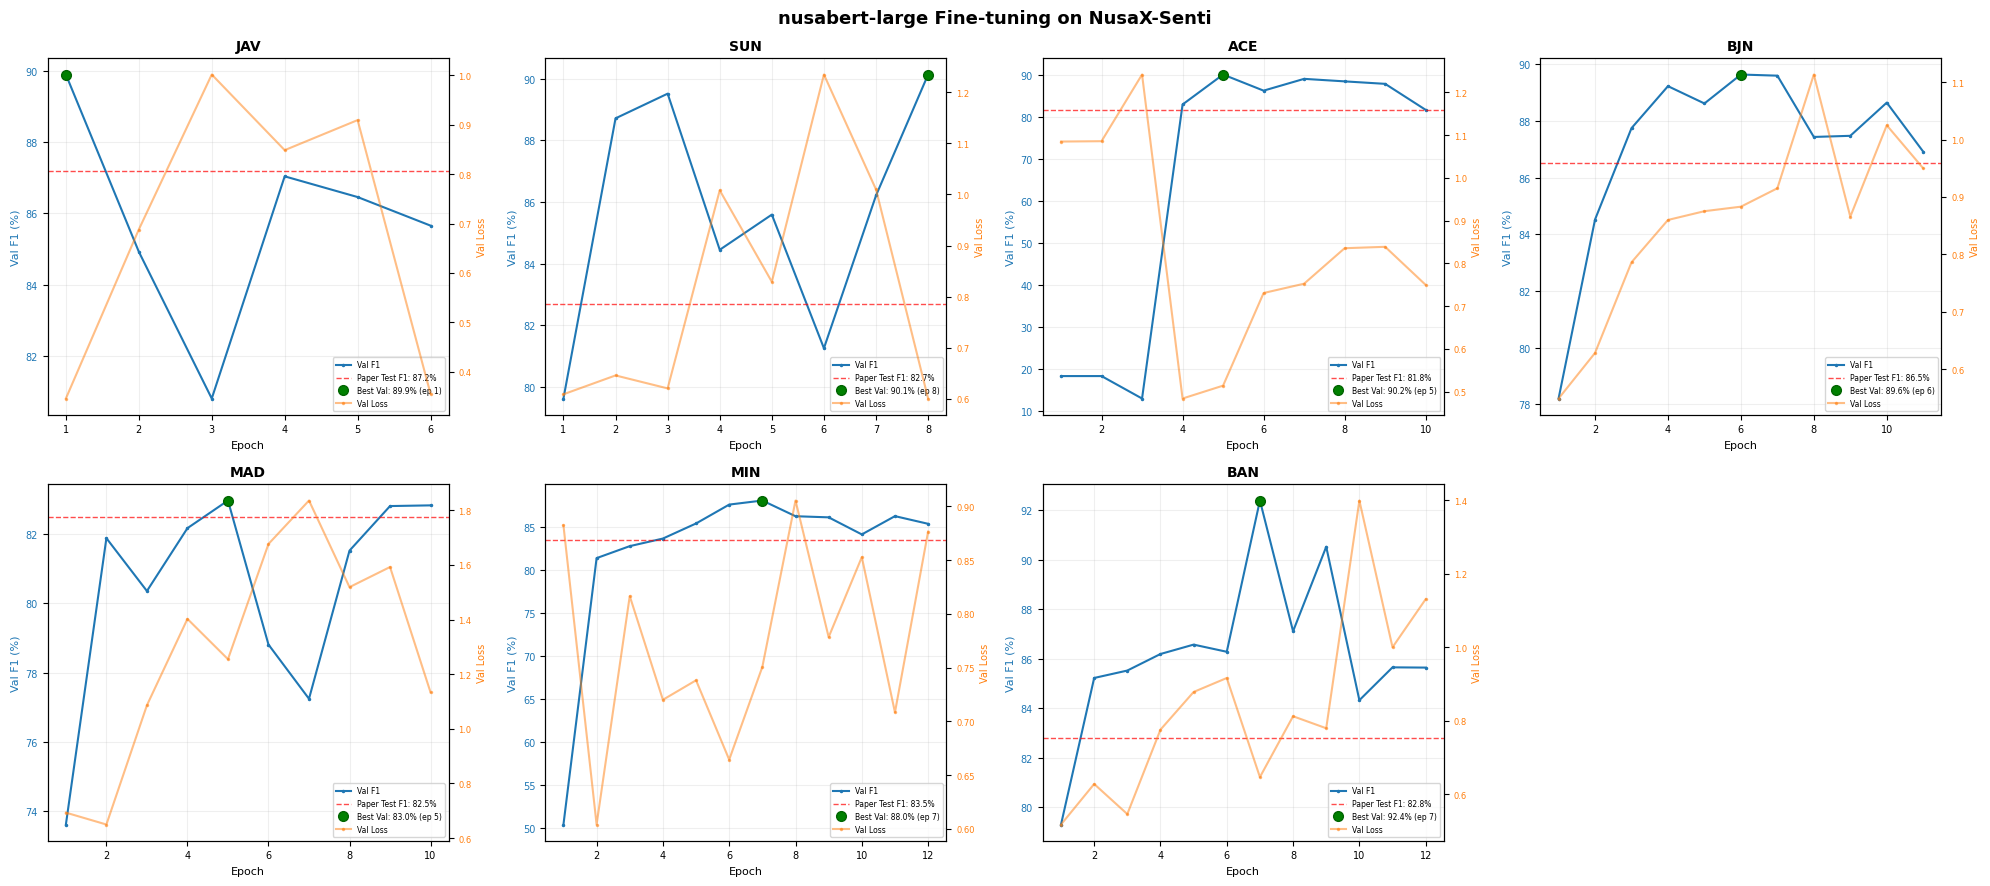

In [17]:
# 1. Training History Plot
langs_with_history = [l for l in ALL_LANGS if (BASE_DIR / f"{MODEL_NAME}-{l}" / "train_history.json").exists()]
n = len(langs_with_history)

if n == 0:
    print("No training history found!")
else:
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4.5 * rows))
    axes = axes.flatten()
    
    for idx, lang in enumerate(langs_with_history):
        with open(BASE_DIR / f"{MODEL_NAME}-{lang}" / "train_history.json") as f:
            history = json.load(f)
        
        # Deduplicate per epoch (ambil terakhir)
        eval_entries = [h for h in history if "eval_f1" in h]
        seen_epochs = {}
        for h in eval_entries:
            seen_epochs[h["epoch"]] = h
        eval_entries = list(seen_epochs.values())
        
        epochs = [h["epoch"] for h in eval_entries]
        f1s = [h["eval_f1"] * 100 for h in eval_entries]
        losses = [h["eval_loss"] for h in eval_entries]
        
        ax = axes[idx]
        
        # Val F1 (biru)
        l1, = ax.plot(epochs, f1s, marker=".", markersize=3, color="tab:blue", linewidth=1.5, label="Val F1")
        ax.set_xlabel("Epoch", fontsize=8)
        ax.set_ylabel("Val F1 (%)", color="tab:blue", fontsize=8)
        ax.tick_params(axis="y", labelcolor="tab:blue", labelsize=7)
        ax.tick_params(axis="x", labelsize=7)
        # ax.set_xlim(epochs[0], epochs[-1])
        
        # Paper Test F1 reference (merah putus-putus)
        # Note: ini F1 pada TEST set dari paper, bukan val set
        paper_f1 = paper_scores.get(lang, 0)
        l2 = ax.axhline(y=paper_f1, color="red", linestyle="--", linewidth=1, alpha=0.7,
                         label=f"Paper Test F1: {paper_f1}%")
        
        # Best val F1 (titik hijau)
        best_f1 = max(f1s)
        best_epoch = epochs[f1s.index(best_f1)]
        l3, = ax.plot(best_epoch, best_f1, "o", color="green", markersize=7, zorder=5,
                      markeredgecolor="darkgreen", markeredgewidth=1,
                      label=f"Best Val: {best_f1:.1f}% (ep {best_epoch:.0f})")
        
        ax.set_title(f"{lang.upper()}", fontsize=10, fontweight="bold")
        ax.grid(True, alpha=0.2)
        
        # Val Loss (orange)
        ax2 = ax.twinx()
        l4, = ax2.plot(epochs, losses, marker=".", markersize=3, color="tab:orange", alpha=0.5,
                       linewidth=1.5, label="Val Loss")
        ax2.set_ylabel("Val Loss", fontsize=7, color="tab:orange")
        ax2.tick_params(axis="y", labelcolor="tab:orange", labelsize=6)
        # ax2.set_xlim(epochs[0], epochs[-1])
        
        # Legend gabungan
        lines = [l1, l2, l3, l4]
        labels = [l.get_label() for l in lines]
        ax.legend(lines, labels, loc="lower right", fontsize=5.5)
    
    for idx in range(n, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(f"{MODEL_NAME} Fine-tuning on NusaX-Senti", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

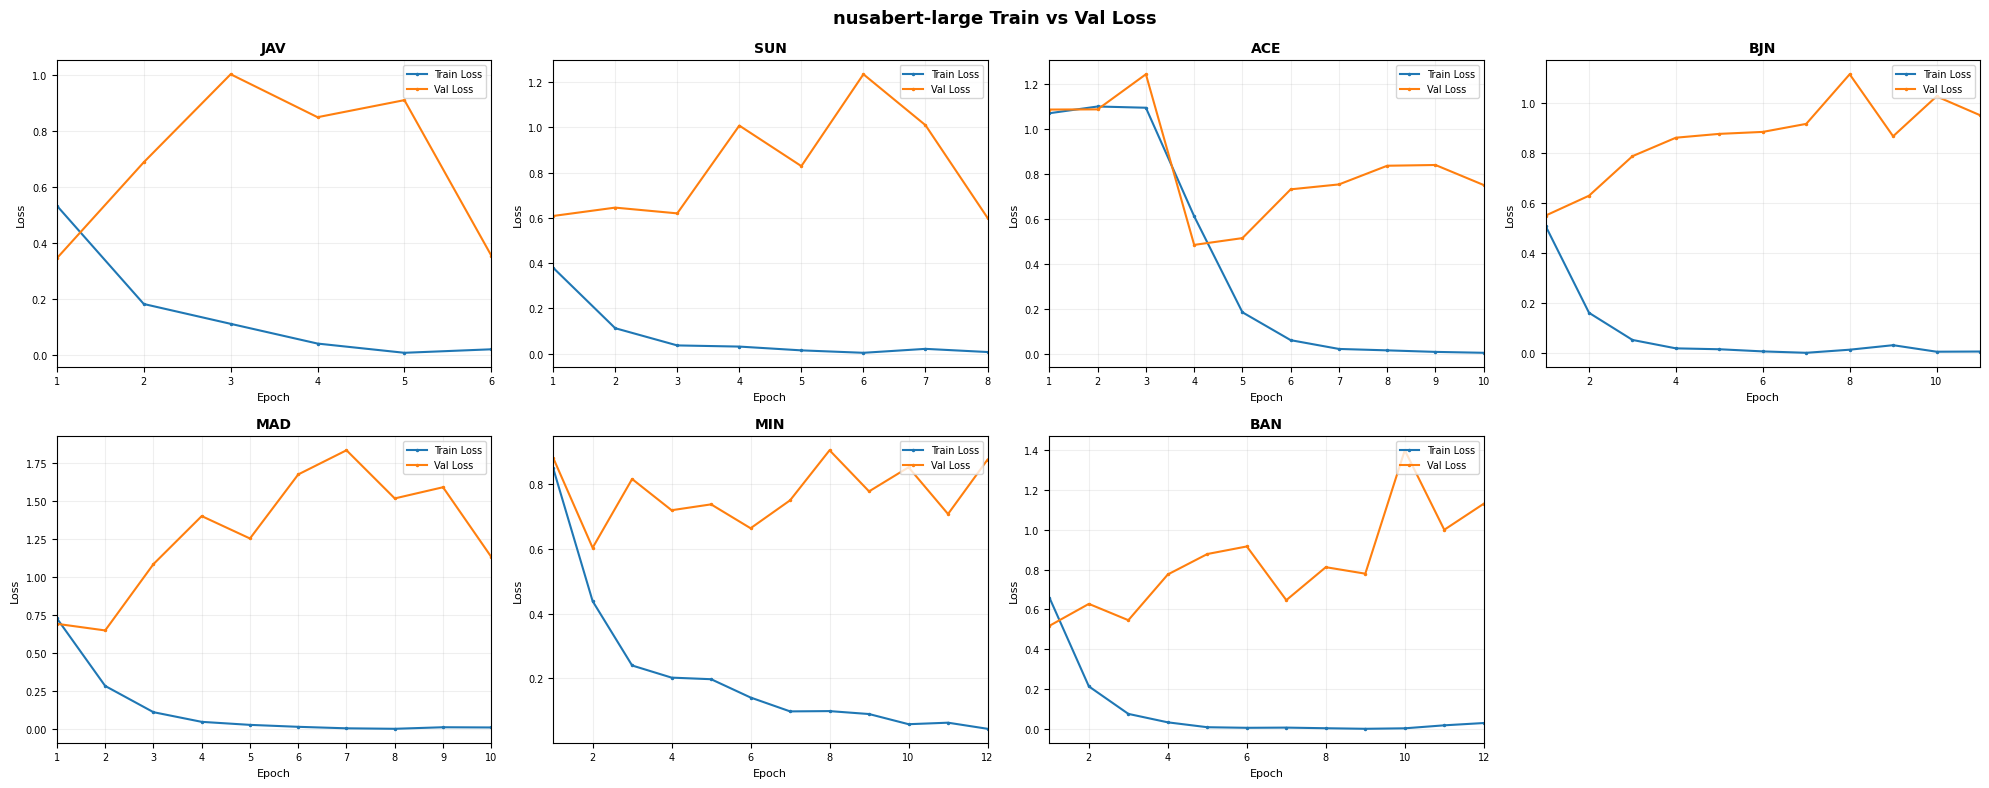

In [23]:
# 1b. Train Loss vs Val Loss (jika train loss tersedia di history)
# Perlu re-train dengan logging_strategy="epoch" untuk mendapatkan train loss per epoch

langs_with_train_loss = []
for lang in ALL_LANGS:
    history_path = BASE_DIR / f"{MODEL_NAME}-{lang}" / "train_history.json"
    if not history_path.exists():
        continue
    with open(history_path) as f:
        history = json.load(f)
    has_train = any("loss" in h and "eval_loss" not in h for h in history)
    if has_train:
        langs_with_train_loss.append(lang)

if not langs_with_train_loss:
    print("Train loss per epoch tidak tersedia di history saat ini.")
    print("Re-train dengan logging_strategy='epoch' di script untuk mendapatkan train loss.")
else:
    n = len(langs_with_train_loss)
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten() if n > 1 else [axes]
    
    for idx, lang in enumerate(langs_with_train_loss):
        with open(BASE_DIR / f"{MODEL_NAME}-{lang}" / "train_history.json") as f:
            history = json.load(f)
        
        train_entries = [h for h in history if "loss" in h and "eval_loss" not in h]
        eval_entries = [h for h in history if "eval_loss" in h]
        seen = {}
        for h in eval_entries:
            seen[h["epoch"]] = h
        eval_entries = list(seen.values())
        
        train_epochs = [h["epoch"] for h in train_entries]
        train_loss = [h["loss"] for h in train_entries]
        eval_epochs = [h["epoch"] for h in eval_entries]
        val_loss = [h["eval_loss"] for h in eval_entries]
        
        ax = axes[idx]
        ax.plot(train_epochs, train_loss, marker=".", markersize=3, color="tab:blue",
                linewidth=1.5, label="Train Loss")
        ax.plot(eval_epochs, val_loss, marker=".", markersize=3, color="tab:orange",
                linewidth=1.5, label="Val Loss")
        
        ax.set_xlabel("Epoch", fontsize=8)
        ax.set_ylabel("Loss", fontsize=8)
        ax.tick_params(labelsize=7)
        all_epochs = train_epochs + eval_epochs
        if all_epochs:
            ax.set_xlim(min(all_epochs), max(all_epochs))
        ax.set_title(f"{lang.upper()}", fontsize=10, fontweight="bold")
        ax.legend(loc="upper right", fontsize=7)
        ax.grid(True, alpha=0.2)
    
    for idx in range(n, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(f"{MODEL_NAME} Train vs Val Loss", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

Plotting 7 bahasa: ['jav', 'sun', 'ace', 'bjn', 'mad', 'min', 'ban']


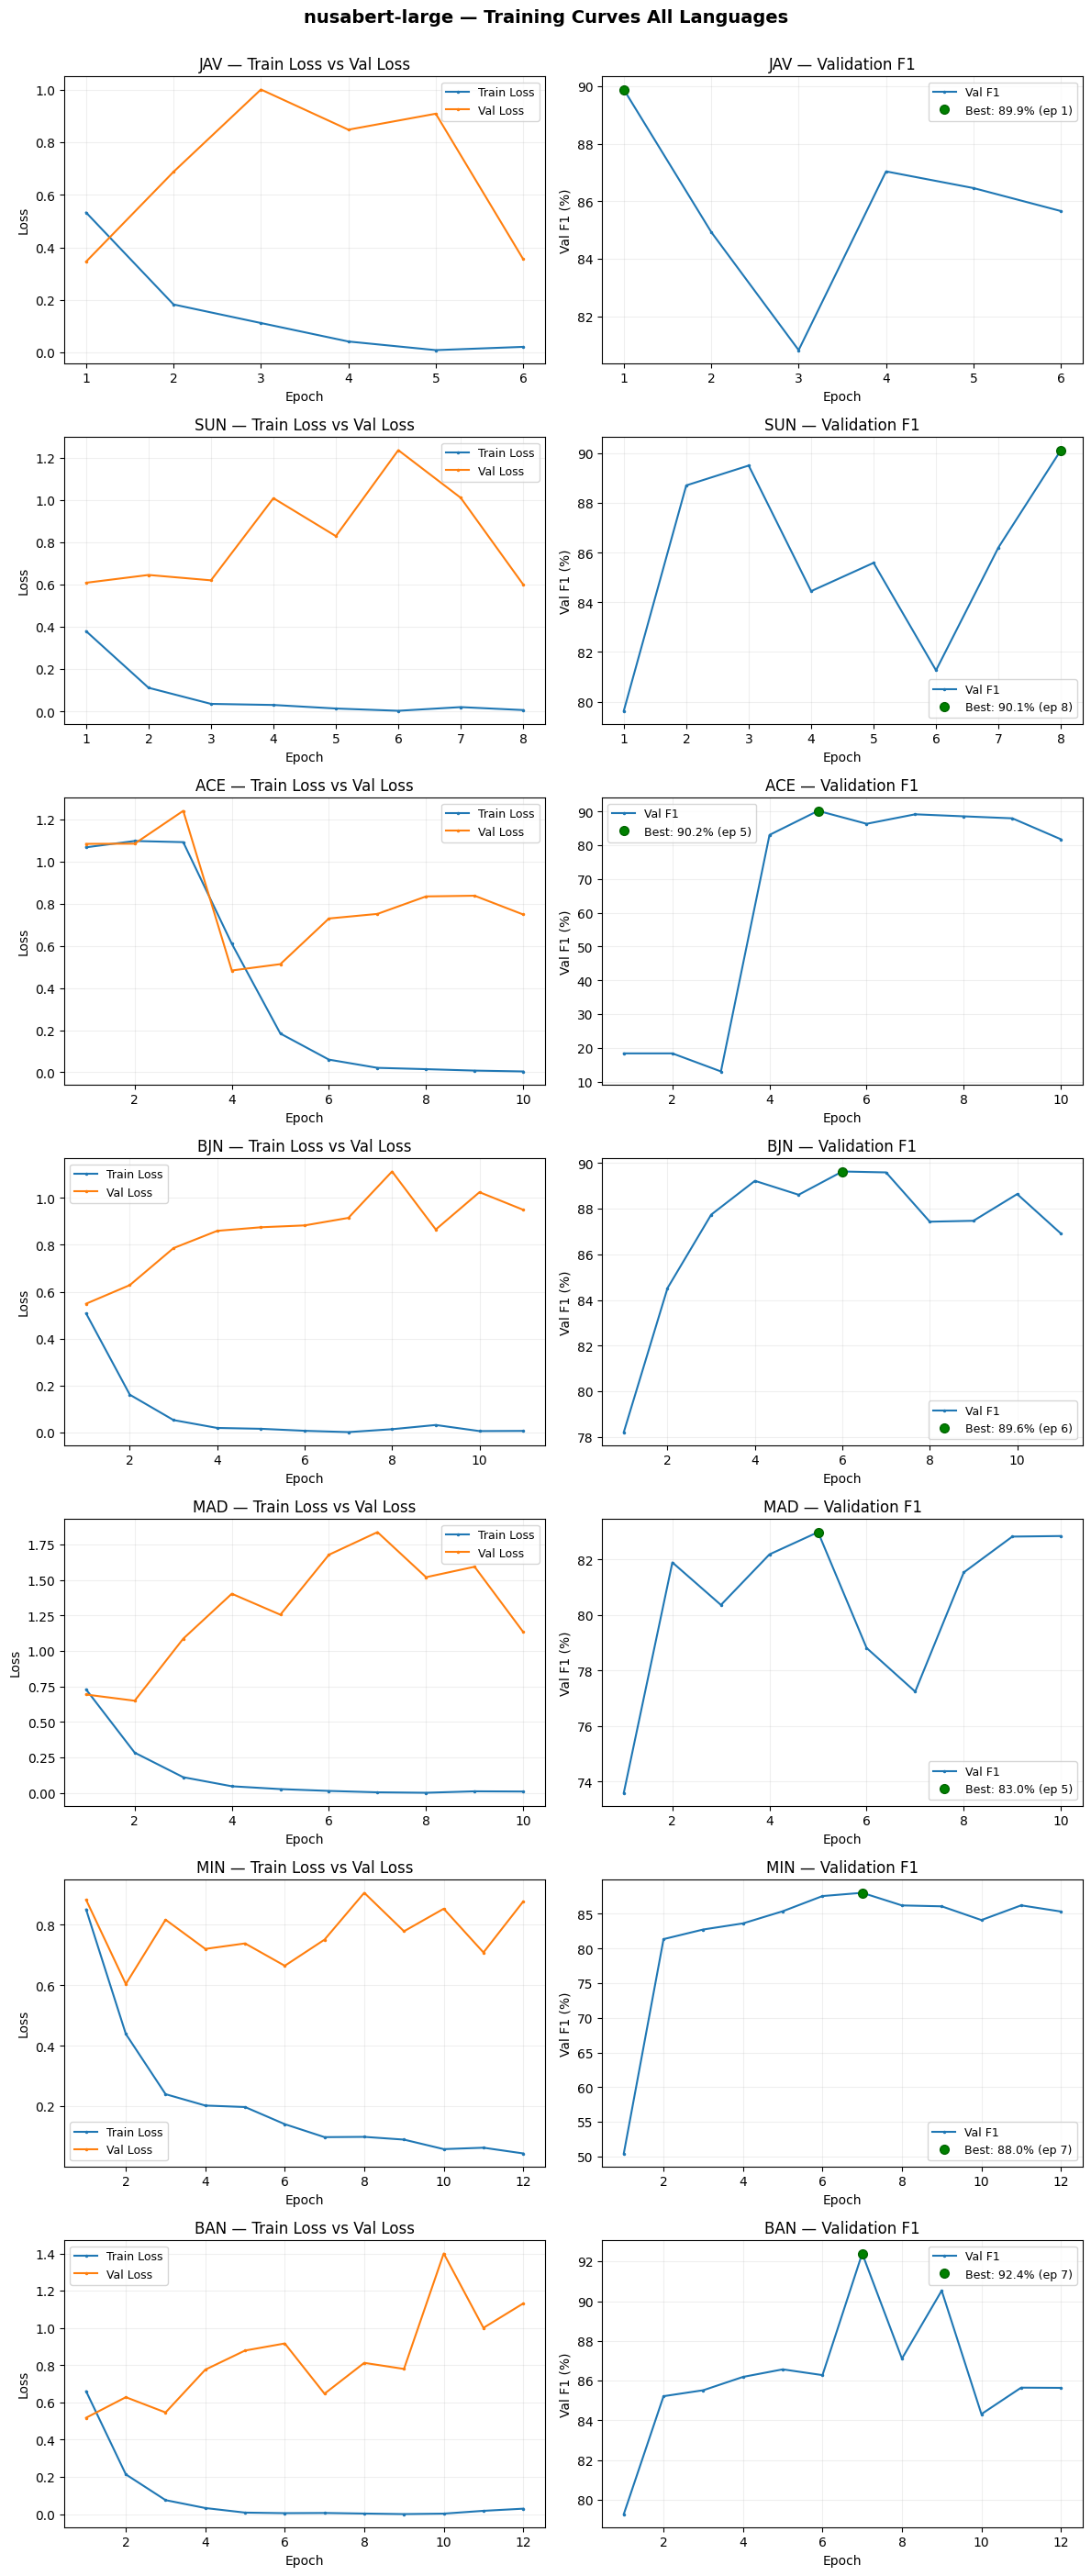

In [29]:
# Load training history per bahasa, plot train loss vs val loss + val F1 untuk SEMUA bahasa
import json
import matplotlib.pyplot as plt

# Cek bahasa yang sudah ada history file-nya
langs_with_history = []
for lang in ALL_LANGS:
    history_file = BASE_DIR / f"{MODEL_NAME}-{lang}" / "train_history.json"
    if history_file.exists():
        langs_with_history.append(lang)

if not langs_with_history:
    print("⚠️  Belum ada training history untuk bahasa manapun.")
else:
    n = len(langs_with_history)
    print(f"Plotting {n} bahasa: {langs_with_history}")

    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
    if n == 1:
        axes = axes.reshape(1, 2)  # ensure 2D shape for single lang

    for row, lang in enumerate(langs_with_history):
        history_file = BASE_DIR / f"{MODEL_NAME}-{lang}" / "train_history.json"
        with open(history_file) as f:
            history = json.load(f)

        train_entries = [h for h in history if "loss" in h and "eval_loss" not in h]
        eval_entries = [h for h in history if "eval_loss" in h]

        # Dedupe eval entries by epoch
        seen = {}
        for h in eval_entries:
            seen[h["epoch"]] = h
        eval_entries = list(seen.values())

        train_epochs = [h["epoch"] for h in train_entries]
        train_loss = [h["loss"] for h in train_entries]
        eval_epochs = [h["epoch"] for h in eval_entries]
        val_loss = [h["eval_loss"] for h in eval_entries]
        val_f1 = [h["eval_f1"] * 100 for h in eval_entries]

        # Subplot kiri: loss
        ax1 = axes[row, 0]
        ax1.plot(train_epochs, train_loss, marker=".", markersize=3, color="tab:blue", linewidth=1.5, label="Train Loss")
        ax1.plot(eval_epochs, val_loss, marker=".", markersize=3, color="tab:orange", linewidth=1.5, label="Val Loss")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Loss")
        ax1.set_title(f"{lang.upper()} — Train Loss vs Val Loss")
        ax1.legend(fontsize=9)
        ax1.grid(True, alpha=0.2)

        # Subplot kanan: val F1
        ax2 = axes[row, 1]
        ax2.plot(eval_epochs, val_f1, marker=".", markersize=3, color="tab:blue", linewidth=1.5, label="Val F1")
        if val_f1:
            best_f1 = max(val_f1)
            best_ep = eval_epochs[val_f1.index(best_f1)]
            ax2.plot(best_ep, best_f1, "o", color="green", markersize=7, markeredgecolor="darkgreen",
                     markeredgewidth=1, label=f"Best: {best_f1:.1f}% (ep {best_ep:.0f})")
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Val F1 (%)")
        ax2.set_title(f"{lang.upper()} — Validation F1")
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.2)

    plt.suptitle(f"{MODEL_NAME} — Training Curves All Languages", fontsize=14, fontweight="bold", y=1.001)
    plt.tight_layout()
    plt.show()


In [24]:
# 2. Evaluate semua model pada test set
f1_metric = evaluate.load("f1")
accuracy_metric = evaluate.load("accuracy")

results = {}
for lang in ALL_LANGS:
    model_path = BASE_DIR / f"{MODEL_NAME}-{lang}" / "best"
    if not model_path.exists():
        continue
    
    clf = pipeline("text-classification", model=str(model_path), tokenizer=str(model_path),
                   device=0 if torch.cuda.is_available() else -1, top_k=None)
    
    test_df = pd.read_csv(DATA_DIR / lang / "test.csv")
    preds_raw = clf(test_df["text"].tolist(), batch_size=64)
    pred_labels = [max(p, key=lambda x: x["score"])["label"] for p in preds_raw]
    
    label_list = sorted(set(test_df["label"]))
    label2id = {v: i for i, v in enumerate(label_list)}
    true_ids = [label2id[l] for l in test_df["label"]]
    pred_ids = [label2id[l] for l in pred_labels]
    
    f1 = f1_metric.compute(predictions=pred_ids, references=true_ids, average="macro")["f1"]
    acc = accuracy_metric.compute(predictions=pred_ids, references=true_ids)["accuracy"]
    results[lang] = {"f1": f1 * 100, "accuracy": acc * 100}
    
    del clf
    torch.cuda.empty_cache()

# Tabel ringkasan
summary = []
for lang in ALL_LANGS:
    if lang not in results:
        continue
    summary.append({
        "Language": lang,
        "Our F1 (%)": round(results[lang]["f1"], 2),
        "Paper F1 (%)": paper_scores[lang],
        "Diff (%)": round(results[lang]["f1"] - paper_scores[lang], 2),
        "Our Acc (%)": round(results[lang]["accuracy"], 2),
    })

df_summary = pd.DataFrame(summary)
print("NusaBERT-large on NusaX-Senti test set")
print("=" * 50)
display(df_summary)
print("Paper: NusaBERT (arXiv:2403.01817)")

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 7463.58it/s]


NusaBERT-large on NusaX-Senti test set


,Language,Our F1 (%),Paper F1 (%),Diff (%),Our Acc (%)
0,jav,85.66,87.2,-1.54,86.75
1,sun,90.13,82.7,7.43,90.75
2,ace,81.80,81.8,-0.00,82.75
3,bjn,86.91,86.5,0.41,87.50
4,mad,82.42,82.5,-0.08,83.00
5,min,84.86,83.5,1.36,85.75
6,ban,85.64,82.8,2.84,86.50


Paper: NusaBERT (arXiv:2403.01817)


In [25]:
# 2b. Train F1 vs Val F1 vs Test F1 (best model)
train_val_test = {}
for lang in ALL_LANGS:
    model_path = BASE_DIR / f"{MODEL_NAME}-{lang}" / "best"
    if not model_path.exists():
        continue
    clf = pipeline("text-classification", model=str(model_path), tokenizer=str(model_path),
                   device=0 if torch.cuda.is_available() else -1, top_k=None)
    lang_res = {}
    for split in ["train", "valid", "test"]:
        df = pd.read_csv(DATA_DIR / lang / f"{split}.csv")
        preds_raw = clf(df["text"].tolist(), batch_size=64)
        pred_labels = [max(p, key=lambda x: x["score"])["label"] for p in preds_raw]
        label_list = sorted(set(df["label"]))
        l2i = {v: i for i, v in enumerate(label_list)}
        true_ids = [l2i[l] for l in df["label"]]
        pred_ids = [l2i[l] for l in pred_labels]
        f1 = f1_metric.compute(predictions=pred_ids, references=true_ids, average="macro")["f1"]
        lang_res[split] = f1 * 100
    train_val_test[lang] = lang_res
    del clf
    torch.cuda.empty_cache()

summary = []
for lang in ALL_LANGS:
    if lang not in train_val_test:
        continue
    r = train_val_test[lang]
    summary.append({
        "Language": lang,
        "Train F1 (%)": round(r["train"], 2),
        "Val F1 (%)": round(r["valid"], 2),
        "Test F1 (%)": round(r["test"], 2),
        "Paper F1 (%)": paper_scores.get(lang, 0),
        "Train-Test Gap": round(r["train"] - r["test"], 2),
    })

df_all = pd.DataFrame(summary)
print("Train vs Val vs Test F1 (best model)")
print("=" * 65)
display(df_all)


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 4331.14it/s]


Train vs Val vs Test F1 (best model)


,Language,Train F1 (%),Val F1 (%),Test F1 (%),Paper F1 (%),Train-Test Gap
0,jav,93.89,89.89,85.66,87.2,8.23
1,sun,99.37,89.51,90.13,82.7,9.24
2,ace,99.48,90.22,81.80,81.8,17.68
3,bjn,100.00,89.63,86.91,86.5,13.09
4,mad,100.00,83.85,82.42,82.5,17.58
5,min,98.35,88.03,84.86,83.5,13.48
6,ban,100.00,92.40,85.64,82.8,14.36


## Confusion Matrix & Classification Report per Bahasa

Heatmap confusion matrix dan classification report (precision/recall/F1 per class) untuk tiap bahasa pada **test set**. Ini menunjukkan **per-class performance** — class mana yang paling susah, ada bias prediksi atau tidak.

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 7302.42it/s]


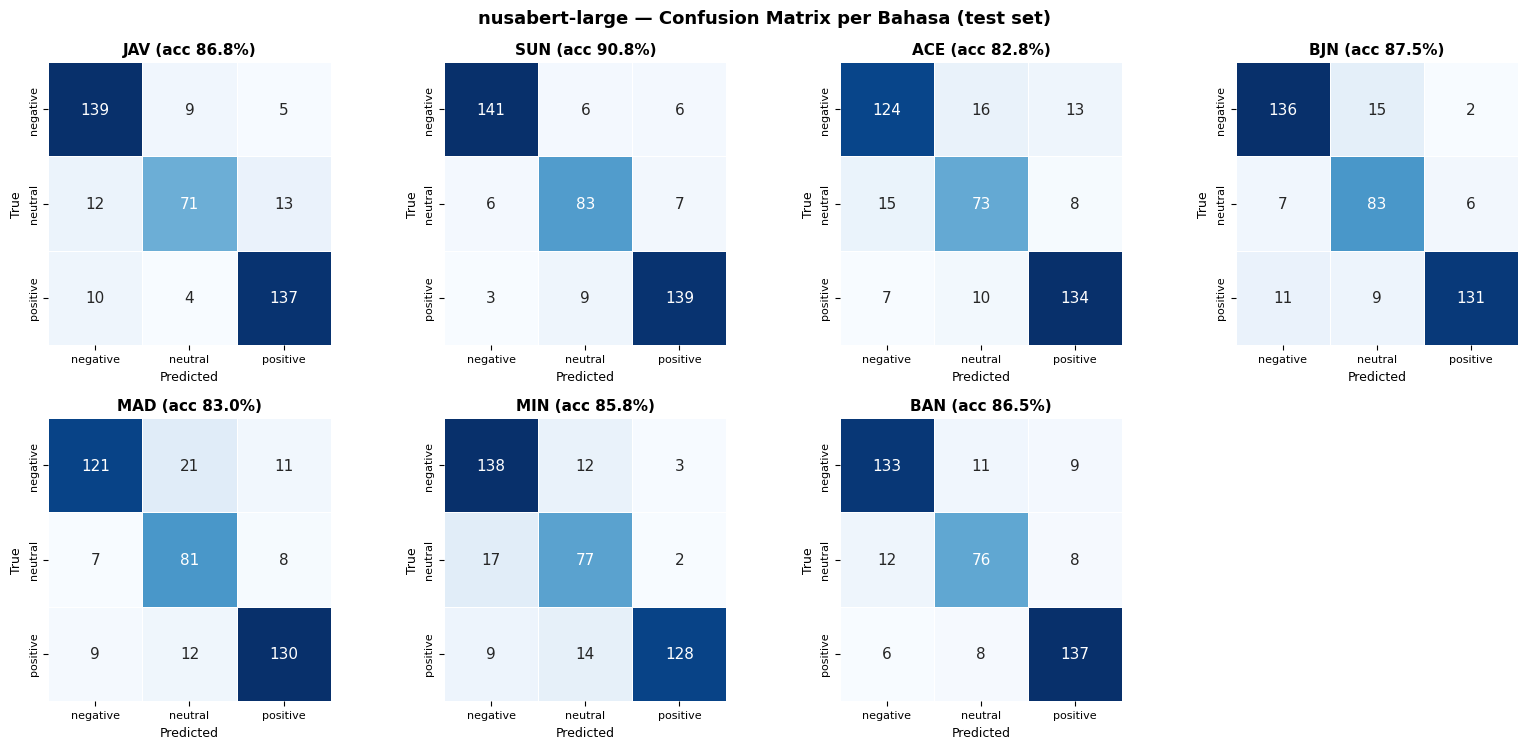


CLASSIFICATION REPORT per BAHASA

[JAV]
              precision    recall  f1-score   support

    negative      0.863     0.908     0.885       153
     neutral      0.845     0.740     0.789        96
    positive      0.884     0.907     0.895       151

    accuracy                          0.868       400
   macro avg      0.864     0.852     0.857       400
weighted avg      0.867     0.868     0.866       400


[SUN]
              precision    recall  f1-score   support

    negative      0.940     0.922     0.931       153
     neutral      0.847     0.865     0.856        96
    positive      0.914     0.921     0.917       151

    accuracy                          0.907       400
   macro avg      0.900     0.902     0.901       400
weighted avg      0.908     0.907     0.908       400


[ACE]
              precision    recall  f1-score   support

    negative      0.849     0.810     0.829       153
     neutral      0.737     0.760     0.749        96
    positive      0.

In [27]:
# Confusion matrix heatmap + classification report per bahasa
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

CLASS_LABELS = ['negative', 'neutral', 'positive']

# Cache prediksi biar gak load model 2x
test_preds = {}
for lang in ALL_LANGS:
    model_path = BASE_DIR / f'{MODEL_NAME}-{lang}' / 'best'
    if not model_path.exists():
        continue
    clf = pipeline('text-classification', model=str(model_path), tokenizer=str(model_path),
                   device=0 if torch.cuda.is_available() else -1, top_k=None)
    test_df = pd.read_csv(DATA_DIR / lang / 'test.csv')
    preds_raw = clf(test_df['text'].tolist(), batch_size=64)
    pred_labels = [max(p, key=lambda x: x['score'])['label'] for p in preds_raw]
    test_preds[lang] = {'true': test_df['label'].tolist(), 'pred': pred_labels}
    del clf
    torch.cuda.empty_cache()

# Plot heatmap grid
n = len(test_preds)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.8 * rows))
axes = axes.flatten() if n > 1 else [axes]

for idx, (lang, data) in enumerate(test_preds.items()):
    cm = confusion_matrix(data['true'], data['pred'], labels=CLASS_LABELS)
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
                ax=ax, cbar=False, square=True, linewidths=0.5,
                annot_kws={'size': 11})
    test_f1 = (cm.diagonal().sum() / cm.sum() * 100)  # accuracy as proxy header
    ax.set_title(f'{lang.upper()} (acc {test_f1:.1f}%)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)
    ax.tick_params(labelsize=8)

for idx in range(n, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f'{MODEL_NAME} — Confusion Matrix per Bahasa (test set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Classification report per bahasa
print('\n' + '=' * 65)
print('CLASSIFICATION REPORT per BAHASA')
print('=' * 65)
for lang, data in test_preds.items():
    print(f'\n[{lang.upper()}]')
    print(classification_report(data['true'], data['pred'],
                                labels=CLASS_LABELS, target_names=CLASS_LABELS,
                                digits=3, zero_division=0))

## Test Predict

Contoh prediksi pada beberapa kalimat per bahasa.

In [28]:
# 3. Test predict
test_sentences = {
    "jav": [
        ("Soto kene saiki rasane wis malih, dadi ora enak koyo jaman biyen.", "positive"),
        ("Pelayanane ala banget, ora profesional", "negative"),
        ("Toko iki buka jam 8 esuk sampek jam 10 bengi", "neutral"),
    ],
    # "sun": [
    #     ("Ulun marasa himung banar kawa bapatamuan lawan pian di sani.", "positive"),
    #     ("Tempatna kotor jeung teu meresih", "negative"),
    #     ("Ieu toko aya di jalan raya", "neutral"),
    # ],
    # "ace": [
    #     ("Syukôreuh that lôn meuteumèë rakan lagèë gata nyang sabé saba ngön lôn.", "positive"),
    #     ("Pelayanan jih jai that, hana sopan", "negative"),
    #     ("Kedai nyoe buka tiep uroe", "neutral"),
    # ],
}

for lang, sentences in test_sentences.items():
    model_path = BASE_DIR / f"{MODEL_NAME}-{lang}" / "best"
    if not model_path.exists():
        continue
    
    clf = pipeline("text-classification", model=str(model_path), tokenizer=str(model_path),
                   device=0 if torch.cuda.is_available() else -1, top_k=None)
    
    print(f"\n{lang.upper()}")
    print("-" * 50)
    
    for text, expected in sentences:
        preds = clf(text)[0]
        preds_sorted = sorted(preds, key=lambda x: x["score"], reverse=True)
        predicted = preds_sorted[0]["label"]
        confidence = preds_sorted[0]["score"]
        
        print(f"  Text: {text}")
        print(f"  Expected: {expected} | Predicted: {predicted} ({confidence:.3f})")
        for p in preds_sorted:
            print(f"    {p['label']:>10}: {p['score']:.4f}")
        print()
    
    del clf
    torch.cuda.empty_cache()

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 6196.38it/s]



JAV
--------------------------------------------------
  Text: Soto kene saiki rasane wis malih, dadi ora enak koyo jaman biyen.
  Expected: positive | Predicted: negative (0.980)
      negative: 0.9805
       neutral: 0.0168
      positive: 0.0027

  Text: Pelayanane ala banget, ora profesional
  Expected: negative | Predicted: negative (0.980)
      negative: 0.9800
       neutral: 0.0172
      positive: 0.0028

  Text: Toko iki buka jam 8 esuk sampek jam 10 bengi
  Expected: neutral | Predicted: neutral (0.996)
       neutral: 0.9959
      negative: 0.0027
      positive: 0.0014



## Verifikasi Mode Kegagalan jav & ace — dari Model Asli (bukan pkl cache)

Load NusaBERT-large **augmented (patience 5)** untuk jav & ace langsung dari `best/`, prediksi ulang test, lalu:
- Tandai tiap kalimat **implisit** (keyword-poor): tidak mengandung marker train yang berasosiasi kuat dengan label benarnya → model tak punya pegangan keyword eksplisit.
- Uji apakah error menumpuk di kalimat implisit (error rate implisit vs eksplisit + χ²).
- Tambah dimensi **confidence**: bedakan *confident-wrong* (model yakin tapi salah) vs ragu.
- Paralel Indonesia (`ind`) ditampilkan agar kalimat bahasa daerah terbaca.

Marker diturunkan dari SEED `train.csv` (leksikon nyata), bukan `train_syn` (sintetis banyak hapax). Verifikasi ini **independen** dari `tmp_pdf/test_predictions_aug.pkl` — hasil pooled 7-bahasa dari pkl: implisit 2.10× lift, p=6e-14, 73% error melibatkan neutral.

In [7]:
import pandas as pd
# === Verifikasi mode kegagalan jav & ace dari MODEL ASLI (independen dari pkl cache) ===
# Pastikan error large-augmented (patience 5) memang menumpuk di kalimat IMPLISIT
# (keyword-poor: tak punya marker train pendukung label benarnya) + lihat confidence.
import re
from collections import Counter, defaultdict
from scipy.stats import chi2_contingency

_tok = lambda s: re.findall(r"\b\w+\b", str(s).lower())

def train_markers(lang, min_tot=2, min_share=0.66):
    """Token dgn asosiasi kuat ke satu label di SEED train = 'explicit marker' yg bisa dipelajari.
    Pakai train.csv (leksikon nyata), bukan train_syn (sintetis banyak hapax)."""
    tr = pd.read_csv(DATA_DIR / lang / "train.csv")
    cnt = defaultdict(Counter)
    for t, l in zip(tr["text"], tr["label"]):
        for w in set(_tok(t)):
            cnt[w][l] += 1
    mk = {}
    for w, c in cnt.items():
        tot = sum(c.values())
        if tot >= min_tot:
            lab, n = c.most_common(1)[0]
            if n / tot >= min_share:
                mk[w] = lab
    return mk

ind_test = pd.read_csv(DATA_DIR / "ind" / "test.csv")["text"].tolist()
FOCUS = ["jav", "ace"]
fail_tables = {}

for lang in FOCUS:
    mp = BASE_DIR / f"{MODEL_NAME}-{lang}" / "best"
    if not mp.exists():
        print(f"{lang}: model tidak ada ({mp})"); continue
    mk = train_markers(lang)
    clf = pipeline("text-classification", model=str(mp), tokenizer=str(mp),
                   device=0 if torch.cuda.is_available() else -1, top_k=None,
                   truncation=True, max_length=128)
    tdf = pd.read_csv(DATA_DIR / lang / "test.csv")
    raw = clf(tdf["text"].tolist(), batch_size=64)
    rows = []
    for i, (text, true) in enumerate(zip(tdf["text"], tdf["label"])):
        sc = sorted(raw[i], key=lambda x: x["score"], reverse=True)
        pred, conf = sc[0]["label"], sc[0]["score"]
        implicit = not any(mk.get(w) == true for w in set(_tok(text)))
        rows.append({"true": true, "pred": pred, "correct": pred == true,
                     "conf": round(conf, 3), "implicit": implicit, "wc": len(_tok(text)),
                     "text": str(text)[:55], "ind": (ind_test[i][:55] if i < len(ind_test) else "")})
    df = pd.DataFrame(rows); fail_tables[lang] = df
    del clf; torch.cuda.empty_cache()

    err = df[~df.correct]; rich = df[~df.implicit]; poor = df[df.implicit]
    er_rich = 1 - rich.correct.mean(); er_poor = 1 - poor.correct.mean()
    ct = pd.crosstab(df.implicit, df.correct)
    p = chi2_contingency(ct)[1] if ct.shape == (2, 2) else float("nan")
    lift = er_poor / er_rich if er_rich else float("nan")
    print(f"\n{'='*64}\n{lang.upper()} large-augmented (patience 5) — acc {df.correct.mean():.1%} | error {len(err)}/{len(df)}")
    print(f"  err IMPLISIT {er_poor:.1%} (n={len(poor)}) vs EKSPLISIT {er_rich:.1%} (n={len(rich)}) | lift {lift:.2f}x | chi2 p={p:.2e}")
    print(f"  dari error -> implisit {err.implicit.mean():.1%} | melibatkan neutral {((err.true=='neutral')|(err.pred=='neutral')).mean():.1%} | confident-wrong(conf>0.9) {(err.conf>0.9).mean():.1%}")
    print("  --- 15 error paling 'confident-wrong' (model yakin tapi salah) ---")
    display(err.sort_values("conf", ascending=False).head(15)[["true","pred","conf","implicit","wc","text","ind"]])


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 2661.55it/s]



JAV large-augmented (patience 5) — acc 86.8% | error 53/400
  err IMPLISIT 25.0% (n=92) vs EKSPLISIT 9.7% (n=308) | lift 2.57x | chi2 p=3.03e-04
  dari error -> implisit 43.4% | melibatkan neutral 71.7% | confident-wrong(conf>0.9) 26.4%
  --- 15 error paling 'confident-wrong' (model yakin tapi salah) ---


,true,pred,conf,implicit,wc,text,ind
11,negative,positive,0.987,True,62,"The peak panggone ning cedeke lembang, waratan...","The peak berlokasi di dekat lembang, dataran t..."
383,neutral,positive,0.985,True,38,Sega uduk iki ana ing dalan rajiman lan bukake...,Nasi uduk ini ada di jalan rajiman dan bukanya...
334,neutral,negative,0.981,False,15,"Minimal internetku pedhot dumadakan, 1 omah ng...","Minimal internet saya putus tiba-tiba, 1 rumah..."
20,neutral,positive,0.977,True,40,Akses menyang dusun bambu isa ditekani kira-ki...,Akses menuju dusun bambu bisa ditempuh kira-ki...
62,neutral,positive,0.966,True,55,"Panggone lumayan unik, rasa panganane biasa, m...","Tempatnya cukup unik, rasa makanan standar, me..."
221,neutral,negative,0.962,False,23,Ning indonesia pilihan merek telepon seluler k...,Di indonesia pilihan merek telepon seluler kan...
88,negative,neutral,0.959,False,19,Parkiran angel bnaget sampek muter ping 3. Sar...,Parkiran susah bener sampai berputar 3x. Saran...
302,neutral,negative,0.958,False,17,"Numpak grab, mase crita sing wingi kena balang...","Naik grab, abangnya cerita yang kemarin kena l..."
295,neutral,positive,0.957,True,62,Aku karo keluarga mangan mbengi nang panggonan...,Saya bersama keluarga makan malam di tempat in...
125,negative,neutral,0.935,True,16,Minimal biaya transaksi wulan 11 sing kudune d...,Minimal biaya transaksi bulan 11 yang harusnya...


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 3121.22it/s]



ACE large-augmented (patience 5) — acc 82.8% | error 69/400
  err IMPLISIT 34.8% (n=69) vs EKSPLISIT 13.6% (n=331) | lift 2.56x | chi2 p=4.86e-05
  dari error -> implisit 34.8% | melibatkan neutral 71.0% | confident-wrong(conf>0.9) 65.2%
  --- 15 error paling 'confident-wrong' (model yakin tapi salah) ---


,true,pred,conf,implicit,wc,text,ind
8,positive,negative,0.999,False,44,Teuakhe jak u hanamasa yumjih sereutoh dua plo...,Terakhir ke hanamasa harganya 120 ribu / orang...
11,negative,positive,0.999,True,70,"The peak meuteumpat di toe lembang, teumpat ma...","The peak berlokasi di dekat lembang, dataran t..."
41,negative,positive,0.999,False,43,Meuci buka puasa inoe. Ngon yum nyang cukop me...,Mencoba untuk buka puasa di sini. Dengan harga...
36,negative,positive,0.999,False,22,"Watee jih trok, meutamah reuloh ju acara nyoe....","Dan ketika dia tiba, makin rusak saja ini acar..."
20,neutral,positive,0.999,True,33,Akses u duson bambu jeuet tajak kira-kira 1 - ...,Akses menuju dusun bambu bisa ditempuh kira-ki...
260,negative,positive,0.999,True,52,"Hek ta atre, hek bak tamita teumpat duek, hek ...","Capek mengantre, capek mencari tempat duduk, c..."
295,neutral,positive,0.999,False,75,Loen ngen keluarga pajoh bue malam di tempat n...,Saya bersama keluarga makan malam di tempat in...
226,neutral,negative,0.999,True,11,Sep teungeuet tiep uroe han hek badan mangat o...,Tidur yang cukup tiap harinya bisa bikin badan...
125,negative,neutral,0.999,False,22,Minimal biaya transaksi nyang mustijih dipulan...,Minimal biaya transaksi bulan 11 yang harusnya...
305,positive,negative,0.998,False,60,Lon termasuk salah sidroe ureueng nyang seutia...,Saya termasuk salah satu orang yang cukup seti...


In [30]:
# import pandas as pd
# import os

# TARGET_LANGS = ["ace", "ban", "bjn", "jav", "mad", "min", "sun"]
# BASE_DIR = "Y:/Michh/Python/Projects/MAGenerator"

# for lang in TARGET_LANGS:
#     synthetic_path = f"{BASE_DIR}/outputs/synthetic/{lang}/synthetic.csv"
#     train_path     = f"{BASE_DIR}/data/nusax_senti/{lang}/train.csv"
#     out_path       = f"{BASE_DIR}/data/nusax_senti/{lang}/syn/train_syn.csv"

#     if not os.path.exists(synthetic_path):
#         print(f"[{lang}] SKIP: synthetic.csv tidak ditemukan ({synthetic_path})")
#         continue

#     os.makedirs(os.path.dirname(out_path), exist_ok=True)

#     train_df = pd.read_csv(train_path)
#     synth_df = pd.read_csv(synthetic_path)

#     # Reassign ID synthetic biar lanjut dari train
#     last_id = train_df["id"].max()
#     synth_df["id"] = range(last_id + 1, last_id + 1 + len(synth_df))

#     train_syn = pd.concat([train_df, synth_df], ignore_index=True)
#     train_syn.to_csv(out_path, index=False, encoding="utf-8")

#     print(f"[{lang}] train={len(train_df)} + synth={len(synth_df)} -> total={len(train_syn)} | saved: {out_path}")


## [OPSIONAL] Gold-Standard: Augmentasi Memperbaiki Apa? (baseline vs augmented)

> **Cell berat & opsional** — load 2 model large/bahasa (baseline seed-only + augmented). Comment kalau tak perlu.

Menjawab pertanyaan kausal: **kenaikan F1 augmentasi karena COVERAGE (kata test baru yang di-cover synthetic) atau AMBIGUITAS/volume?**

Bandingkan prediksi baseline (seed-only) vs augmented pada test:
- **FIXED** = baseline salah → aug benar (yang augmentasi perbaiki). **BROKEN** = baseline benar → aug salah. Net (FIXED−BROKEN) = mekanisme ΔF1.
- **Uji coverage:** di antara kalimat baseline-salah, apakah fix-rate lebih tinggi untuk yang **punya kata baru-dicover**? Kalau ya → coverage menolong. Kalau mirip → bukan coverage.
- **Karakter FIXED/BROKEN:** kalau didominasi implisit/neutral (bukan beda coverage) → gain dari ambiguitas/volume/regularisasi.

**Caveat:** flip = akibat SEMUA perbedaan baseline↔aug (volume + coverage + noise); coverage cuma satu komponen → baca arah, bukan kausal mutlak. Untuk jav/ace (regressor), BROKEN > FIXED (net negatif).

In [8]:
# ════════════════════════════════════════════════════════════════════════
# [OPSIONAL — boleh di-comment kalau tak perlu] GOLD-STANDARD: augmentasi memperbaiki APA?
# Load baseline(seed-only) + augmented, bandingkan prediksi test, karakterisasi flipped.
# Jawab: kenaikan F1 karena COVERAGE (kata test baru di-cover) atau AMBIGUITAS/volume?
# BERAT: load 2 model large/bahasa (~1-2 mnt/bahasa). Ganti FOCUS_GS sesuai kebutuhan.
# ════════════════════════════════════════════════════════════════════════
import re
from collections import Counter, defaultdict

BASELINE_DIR = Path("../outputs/nusabert-sentiment-large")        # seed-only
AUG_DIR      = Path("../outputs/nusabert-sentiment-large-syn")    # augmented (= BASE_DIR)
FOCUS_GS     = ["jav", "ace", "sun", "ban"]   # 2 regressor + 2 winner; pakai ALL_LANGS utk semua
_tk = lambda s: re.findall(r"\b\w+\b", str(s).lower())

def _mk(lang, mt=2, ms=0.66):
    tr = pd.read_csv(DATA_DIR / lang / "train.csv"); cc = defaultdict(Counter)
    for t, l in zip(tr.text, tr.label):
        for w in set(_tk(t)): cc[w][l] += 1
    m = {}
    for w, x in cc.items():
        tot = sum(x.values())
        if tot >= mt:
            lab, n = x.most_common(1)[0]
            if n / tot >= ms: m[w] = lab
    return m

def _pred(mp, texts):
    clf = pipeline("text-classification", model=str(mp), tokenizer=str(mp),
                   device=0 if torch.cuda.is_available() else -1, top_k=None,
                   truncation=True, max_length=128)
    o = [max(r, key=lambda z: z["score"])["label"] for r in clf(texts, batch_size=64)]
    del clf; torch.cuda.empty_cache(); return o

gs_rows = []
for lang in FOCUS_GS:
    bp = BASELINE_DIR / f"{MODEL_NAME}-{lang}" / "best"
    ap = AUG_DIR / f"{MODEL_NAME}-{lang}" / "best"
    if not (bp.exists() and ap.exists()):
        print(f"{lang}: skip (baseline={bp.exists()} aug={ap.exists()})"); continue
    seed = pd.read_csv(DATA_DIR / lang / "train.csv")
    tsn  = pd.read_csv(DATA_DIR / lang / "syn" / "train_syn.csv")
    test = pd.read_csv(DATA_DIR / lang / "test.csv")
    seed_v = set(w for t in seed.text for w in _tk(t))
    newcov = set(w for t in tsn.text for w in _tk(t)) - seed_v   # kata BARU di-cover augmentasi
    mk = _mk(lang)
    texts, true = test.text.tolist(), test.label.tolist()
    print(f"[{lang}] load baseline + augmented ...")
    pb, pa = _pred(bp, texts), _pred(ap, texts)
    for x, t, b, a in zip(texts, true, pb, pa):
        tks = set(_tk(x))
        gs_rows.append({"lang": lang, "true": t, "base_ok": b == t, "aug_ok": a == t,
                        "ncov": len(tks & newcov),
                        "oov_seed": sum(1 for w in tks if w not in seed_v) / max(len(tks), 1),
                        "implicit": not any(mk.get(w) == t for w in tks), "neutral": t == "neutral"})
gs = pd.DataFrame(gs_rows)
gs["flip"] = ["FIXED" if (not r.base_ok and r.aug_ok) else "BROKEN" if (r.base_ok and not r.aug_ok)
              else "both_ok" if r.base_ok else "both_wrong" for r in gs.itertuples()]

print("\n=== Net mekanisme ΔF1 per bahasa (FIXED − BROKEN) ===")
for lang in FOCUS_GS:
    s = gs[gs.lang == lang]
    if not len(s): continue
    f, br = int((s.flip == "FIXED").sum()), int((s.flip == "BROKEN").sum())
    print(f"  {lang}: FIXED={f} BROKEN={br} net={f-br:+d} | base_acc={s.base_ok.mean():.1%} -> aug_acc={s.aug_ok.mean():.1%}")

print("\n=== Apakah FIX karena COVERAGE? (fix-rate di antara baseline-SALAH) ===")
bw = gs[~gs.base_ok]
for sub, nm in [(bw[bw.ncov > 0], "punya kata BARU-dicover"), (bw[bw.ncov == 0], "TANPA kata baru-dicover")]:
    if len(sub): print(f"  {nm:24}: n={len(sub):4} fix-rate(->aug benar)={sub.aug_ok.mean():.1%}")
print("  (kalau fix-rate mirip => coverage BUKAN penyebab fix; kalau jauh lebih tinggi di 'punya' => coverage menolong)")

print("\n=== Karakter FIXED vs BROKEN ===")
for cat in ["FIXED", "BROKEN"]:
    s = gs[gs.flip == cat]
    if len(s):
        print(f"  {cat:7}: n={len(s):4} | implisit={s.implicit.mean():.0%} | neutral={s.neutral.mean():.0%} | "
              f"mean kata-baru-cover={s.ncov.mean():.1f} | mean OOV-vs-seed={s.oov_seed.mean():.1%}")


[jav] load baseline + augmented ...


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 4268.92it/s]


[ace] load baseline + augmented ...


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 4344.20it/s]


[sun] load baseline + augmented ...


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 1649.49it/s]


[ban] load baseline + augmented ...


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 2461.83it/s]



=== Net mekanisme ΔF1 per bahasa (FIXED − BROKEN) ===
  jav: FIXED=22 BROKEN=30 net=-8 | base_acc=88.8% -> aug_acc=86.8%
  ace: FIXED=21 BROKEN=26 net=-5 | base_acc=84.0% -> aug_acc=82.8%
  sun: FIXED=34 BROKEN=14 net=+20 | base_acc=85.8% -> aug_acc=90.8%
  ban: FIXED=29 BROKEN=17 net=+12 | base_acc=83.5% -> aug_acc=86.5%

=== Apakah FIX karena COVERAGE? (fix-rate di antara baseline-SALAH) ===
  punya kata BARU-dicover : n= 156 fix-rate(->aug benar)=44.9%
  TANPA kata baru-dicover : n=  76 fix-rate(->aug benar)=47.4%
  (kalau fix-rate mirip => coverage BUKAN penyebab fix; kalau jauh lebih tinggi di 'punya' => coverage menolong)

=== Karakter FIXED vs BROKEN ===
  FIXED  : n= 106 | implisit=34% | neutral=35% | mean kata-baru-cover=1.3 | mean OOV-vs-seed=22.0%
  BROKEN : n=  87 | implisit=37% | neutral=36% | mean kata-baru-cover=1.2 | mean OOV-vs-seed=21.8%
